In [2]:
import subprocess
import os
import pandas as pd
#import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import gsw as sw
from roms_regrid import *

In [20]:
data=xr.open_mfdataset('/home/x-uheede/S/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_rst.20240[4-9]????????.nc', combine='nested', concat_dim=["time"])

In [21]:
timeseries=data['ALK'].isel(xi_rho=300).isel(eta_rho=200).load()

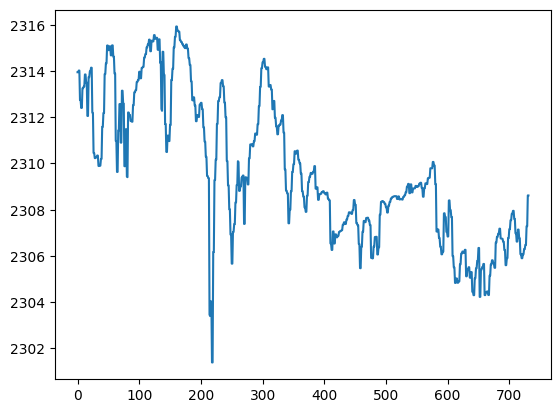

In [22]:
plt.plot(timeseries.isel(s_rho=10))

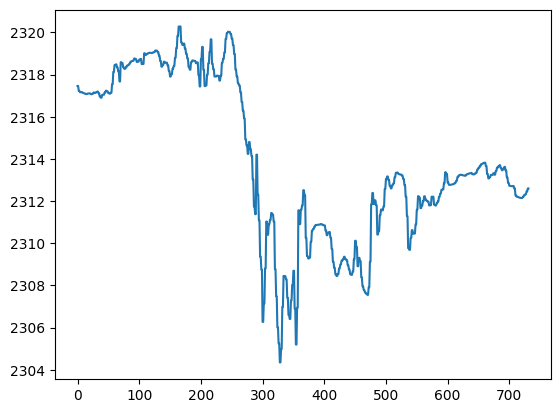

In [5]:
data=xr.open_mfdataset('/home/x-uheede/S/Iceland0_MARBL_2024_extS_60m/Iceland0_MARBL_2024_rst.20240[4-9]????????.nc', combine='nested', concat_dim=["time"])
timeseries_salt=data['salt'].isel(xi_rho=300).isel(eta_rho=200).load()
plt.plot(timeseries.isel(s_rho=59))

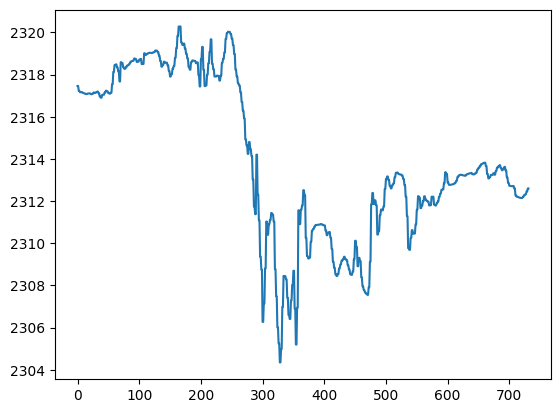

In [4]:
data=xr.open_mfdataset('/home/x-uheede/S/Iceland0_MARBL_2024_extS_60m/Iceland0_MARBL_2024_rst.20240[4-9]????????.nc', combine='nested', concat_dim=["time"])
timeseries=data['ALK'].isel(xi_rho=300).isel(eta_rho=200).load()
plt.plot(timeseries.isel(s_rho=59))

In [6]:
timeseries_alk=timeseries

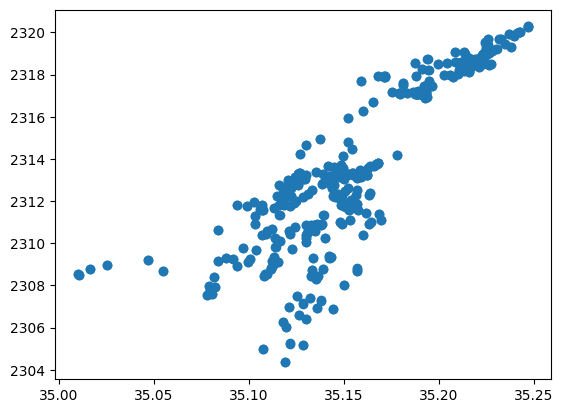

In [8]:
plt.scatter(timeseries_salt.isel(s_rho=59),timeseries_alk.isel(s_rho=59))

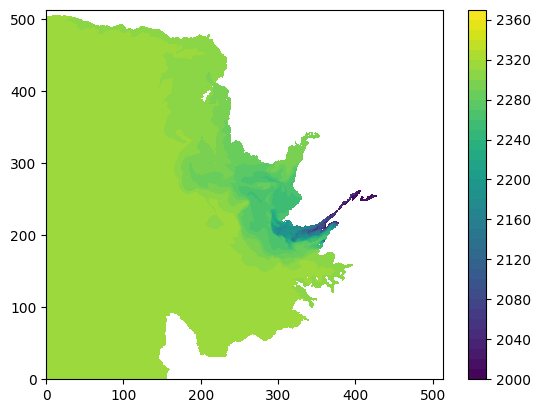

In [17]:
cf=plt.contourf(data['ALK'].isel(s_rho=59).isel(time=90).where(data['ALK'].isel(s_rho=59).isel(time=0)>0),levels=np.arange(2000,2380,10))
plt.colorbar(cf)

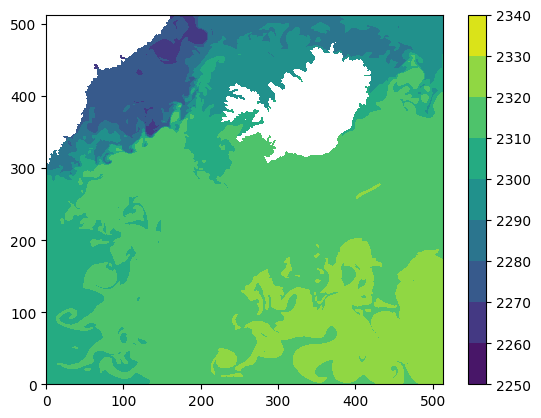

In [6]:
cf=plt.contourf(data['ALK'].isel(s_rho=59).isel(time=0).where(data['ALK'].isel(s_rho=0).isel(time=0)>0),levels=np.arange(2250,2350,10))
plt.colorbar(cf)

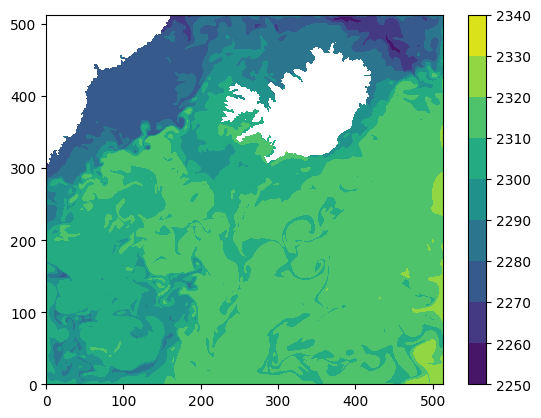

In [30]:
cf=plt.contourf(data['ALK'].isel(s_rho=59).isel(time=400).where(data['ALK'].isel(s_rho=0).isel(time=0)>0),levels=np.arange(2250,2350,10))
plt.colorbar(cf)

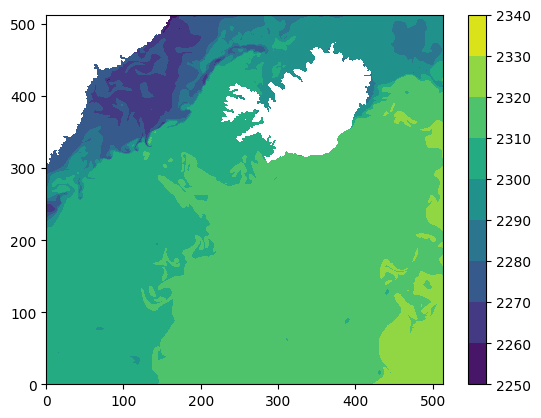

In [3]:
cf=plt.contourf(data['ALK'].isel(s_rho=59).isel(time=700).where(data['ALK'].isel(s_rho=0).isel(time=0)>0),levels=np.arange(2250,2350,10))
plt.colorbar(cf)

Closest grid cell to SW Iceland:
  Lat, Lon = 64.000, 337.000
  Surface ALK = 2324.35
  Surface DIC = 1988.41


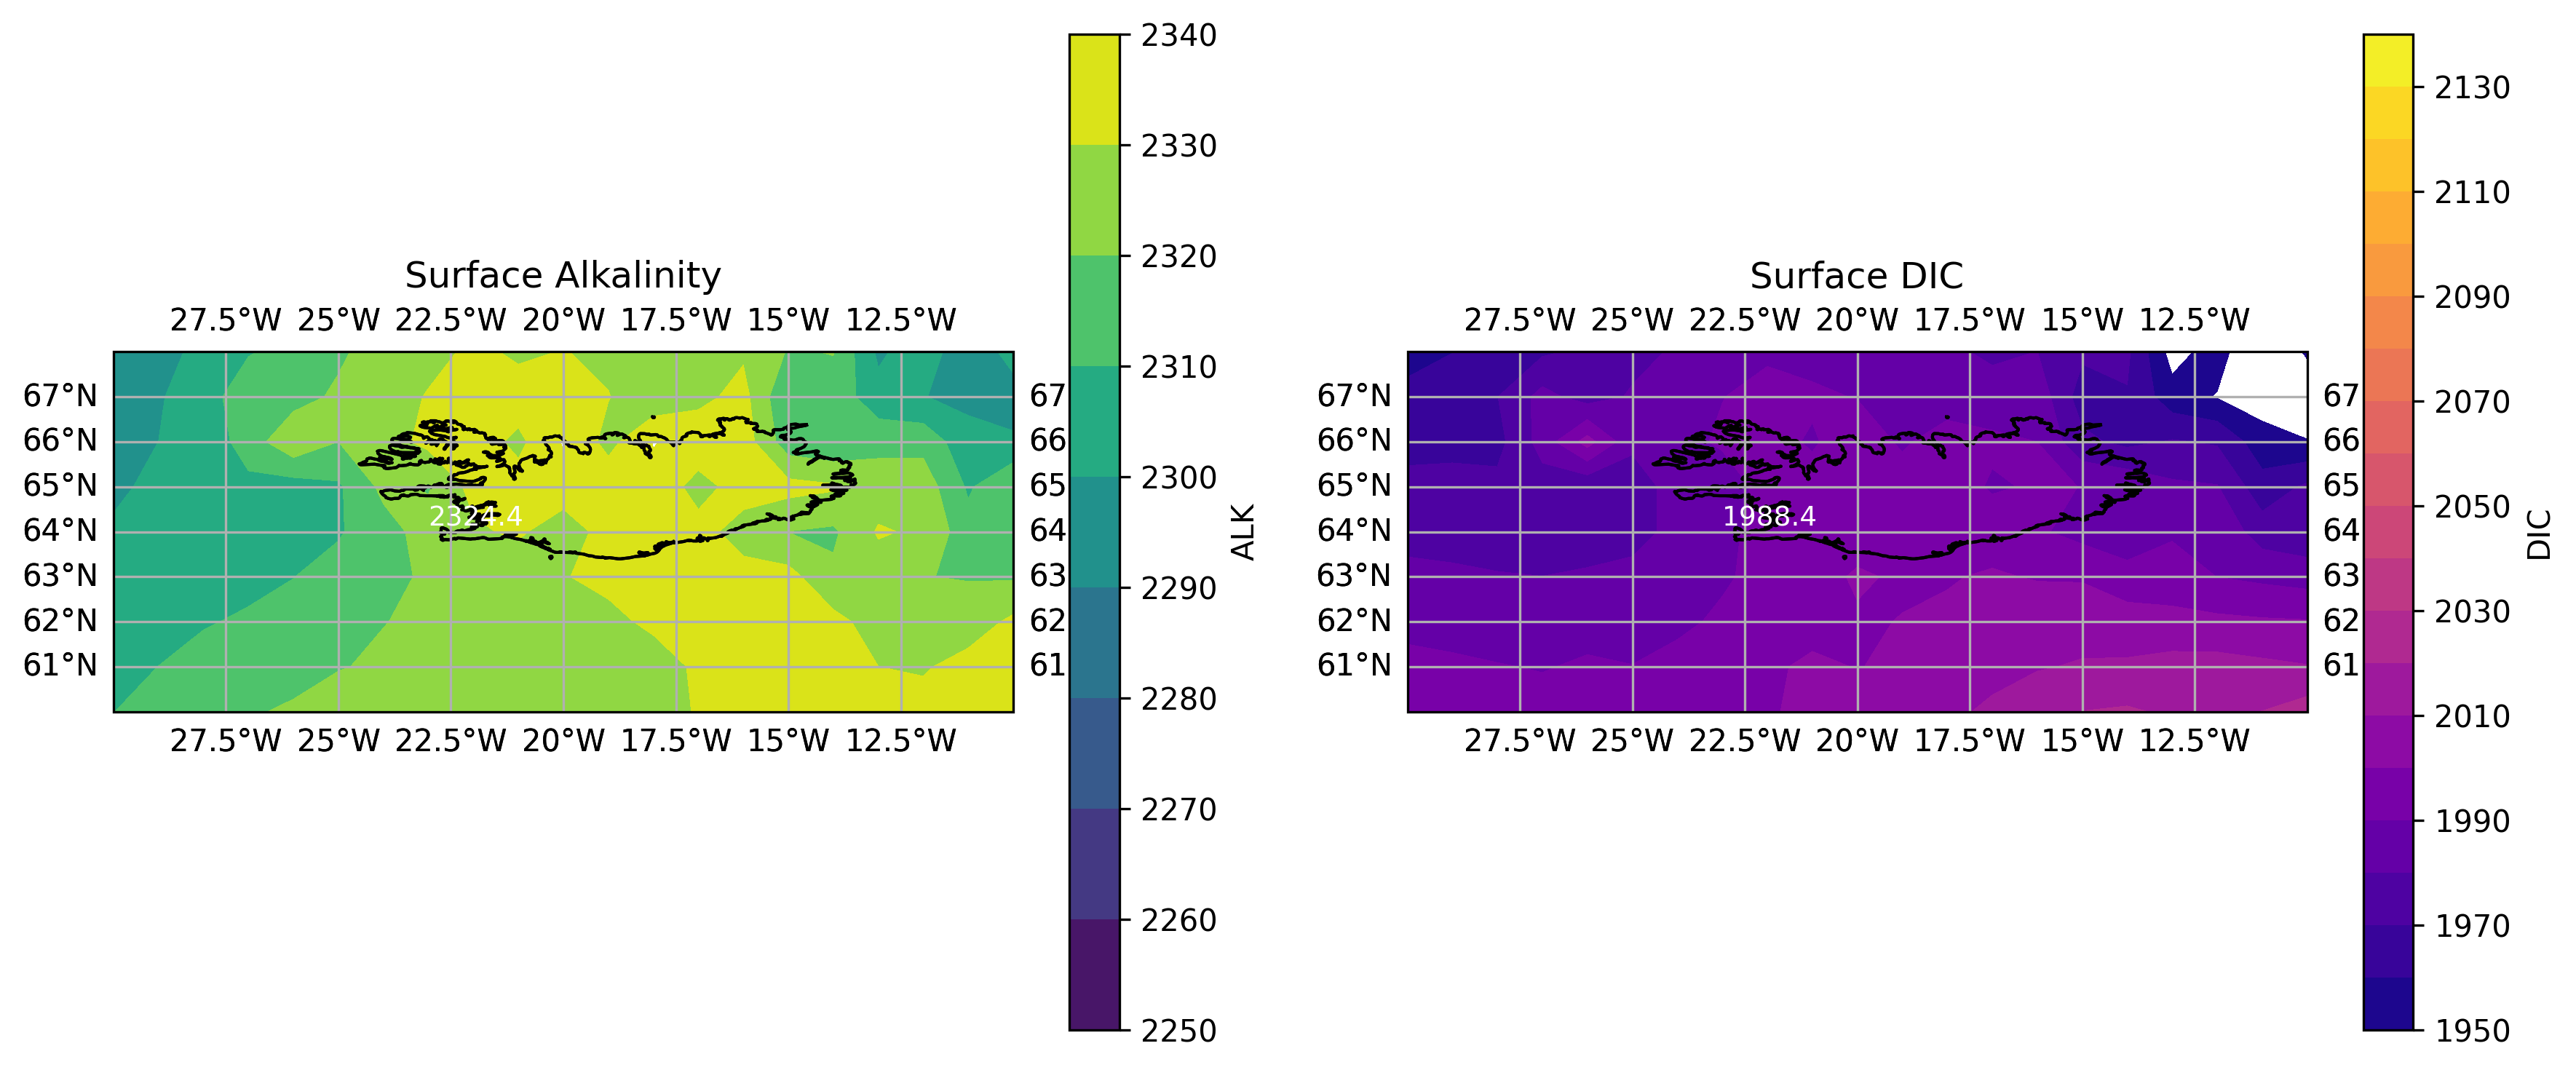

In [47]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --------------------------------------------------
# Open dataset
# --------------------------------------------------
ds = xr.open_dataset(
    "/anvil/projects/x-ees250129/Datasets/UNIFIED/BGCdataset.nc"
)

# --------------------------------------------------
# Select surface layer
# (adjust if your vertical dimension has a different name)
# --------------------------------------------------
if "dep" in ds.dims:
    Alk_surf = ds["Alk"].isel(dep=0)
    DIC_surf = ds["DIC"].isel(dep=0)
elif "z" in ds.dims:
    Alk_surf = ds["Alk"].isel(z=0)
    DIC_surf = ds["DIC"].isel(z=0)
else:
    raise ValueError("No recognized vertical dimension found.")

# --------------------------------------------------
# Coordinates
# --------------------------------------------------
lat = ds["lat"]
lon = ds["lon"]

# --------------------------------------------------
# Southwest Iceland reference point
# (near Reykjanes Peninsula)
# --------------------------------------------------
lat_sw = 63.8
lon_sw = -22.5

# Convert lon if dataset is 0–360
if lon.max() > 180:
    lon_sw = lon_sw % 360

# --------------------------------------------------
# Find nearest grid cell
# --------------------------------------------------
dist2 = (lat - lat_sw)**2 + (lon - lon_sw)**2
j, i = np.unravel_index(dist2.argmin().values, dist2.shape)

lat_pt = lat[j].values
lon_pt = lon[i].values

alk_pt = Alk_surf[0,j, i].values
dic_pt = DIC_surf[0,j, i].values

print(f"Closest grid cell to SW Iceland:")
print(f"  Lat, Lon = {lat_pt:.3f}, {lon_pt:.3f}")
print(f"  Surface ALK = {alk_pt:.2f}")
print(f"  Surface DIC = {dic_pt:.2f}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axs = plt.subplots(
    ncols=2,
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300
)

# ---- ALK ----
cf1 = axs[0].contourf(
    lon, lat, Alk_surf.isel(month=0),
    levels=np.arange(2250,2350,10),
    cmap="viridis",
    transform=ccrs.PlateCarree()
)
axs[0].plot(lon_pt, lat_pt, "ro", transform=ccrs.Mercator())
axs[0].set_title("Surface Alkalinity")
plt.colorbar(cf1, ax=axs[0], orientation="vertical", label="ALK")

axs[0].text(
    lon_pt, lat_pt,
    f"{alk_pt:.1f}",
    color="white",
    fontsize=9,
    ha="left",
    va="bottom",
    transform=ccrs.PlateCarree()
)

# ---- DIC ----
cf2 = axs[1].contourf(
    lon, lat, DIC_surf.isel(month=0),
    levels=np.arange(1950,2150,10),
    cmap="plasma",
    transform=ccrs.PlateCarree()
)
axs[1].plot(lon_pt, lat_pt, "ro", transform=ccrs.Mercator())
axs[1].set_title("Surface DIC")
plt.colorbar(cf2, ax=axs[1], orientation="vertical", label="DIC")

axs[1].text(
    lon_pt, lat_pt,
    f"{dic_pt:.1f}",
    color="white",
    fontsize=9,
    ha="left",
    va="bottom",
    transform=ccrs.PlateCarree()
)

for ax in axs:
    ax.coastlines()
    ax.gridlines(draw_labels=True)


# --------------------------------------------------
# (SW Iceland–centered, but includes whole island)
lon_min, lon_max = -30, -10
lat_min, lat_max = 60, 68

axs[0].set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())
axs[0].coastlines(resolution="10m")
axs[0].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

axs[1].set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())
axs[1].coastlines(resolution="10m")
axs[1].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)



plt.tight_layout()
plt.show()


Closest grid cell to SW Iceland:
  Lat, Lon = 64.000, 337.000
  Surface ALK = 2334.86
  Surface DIC = 2013.10


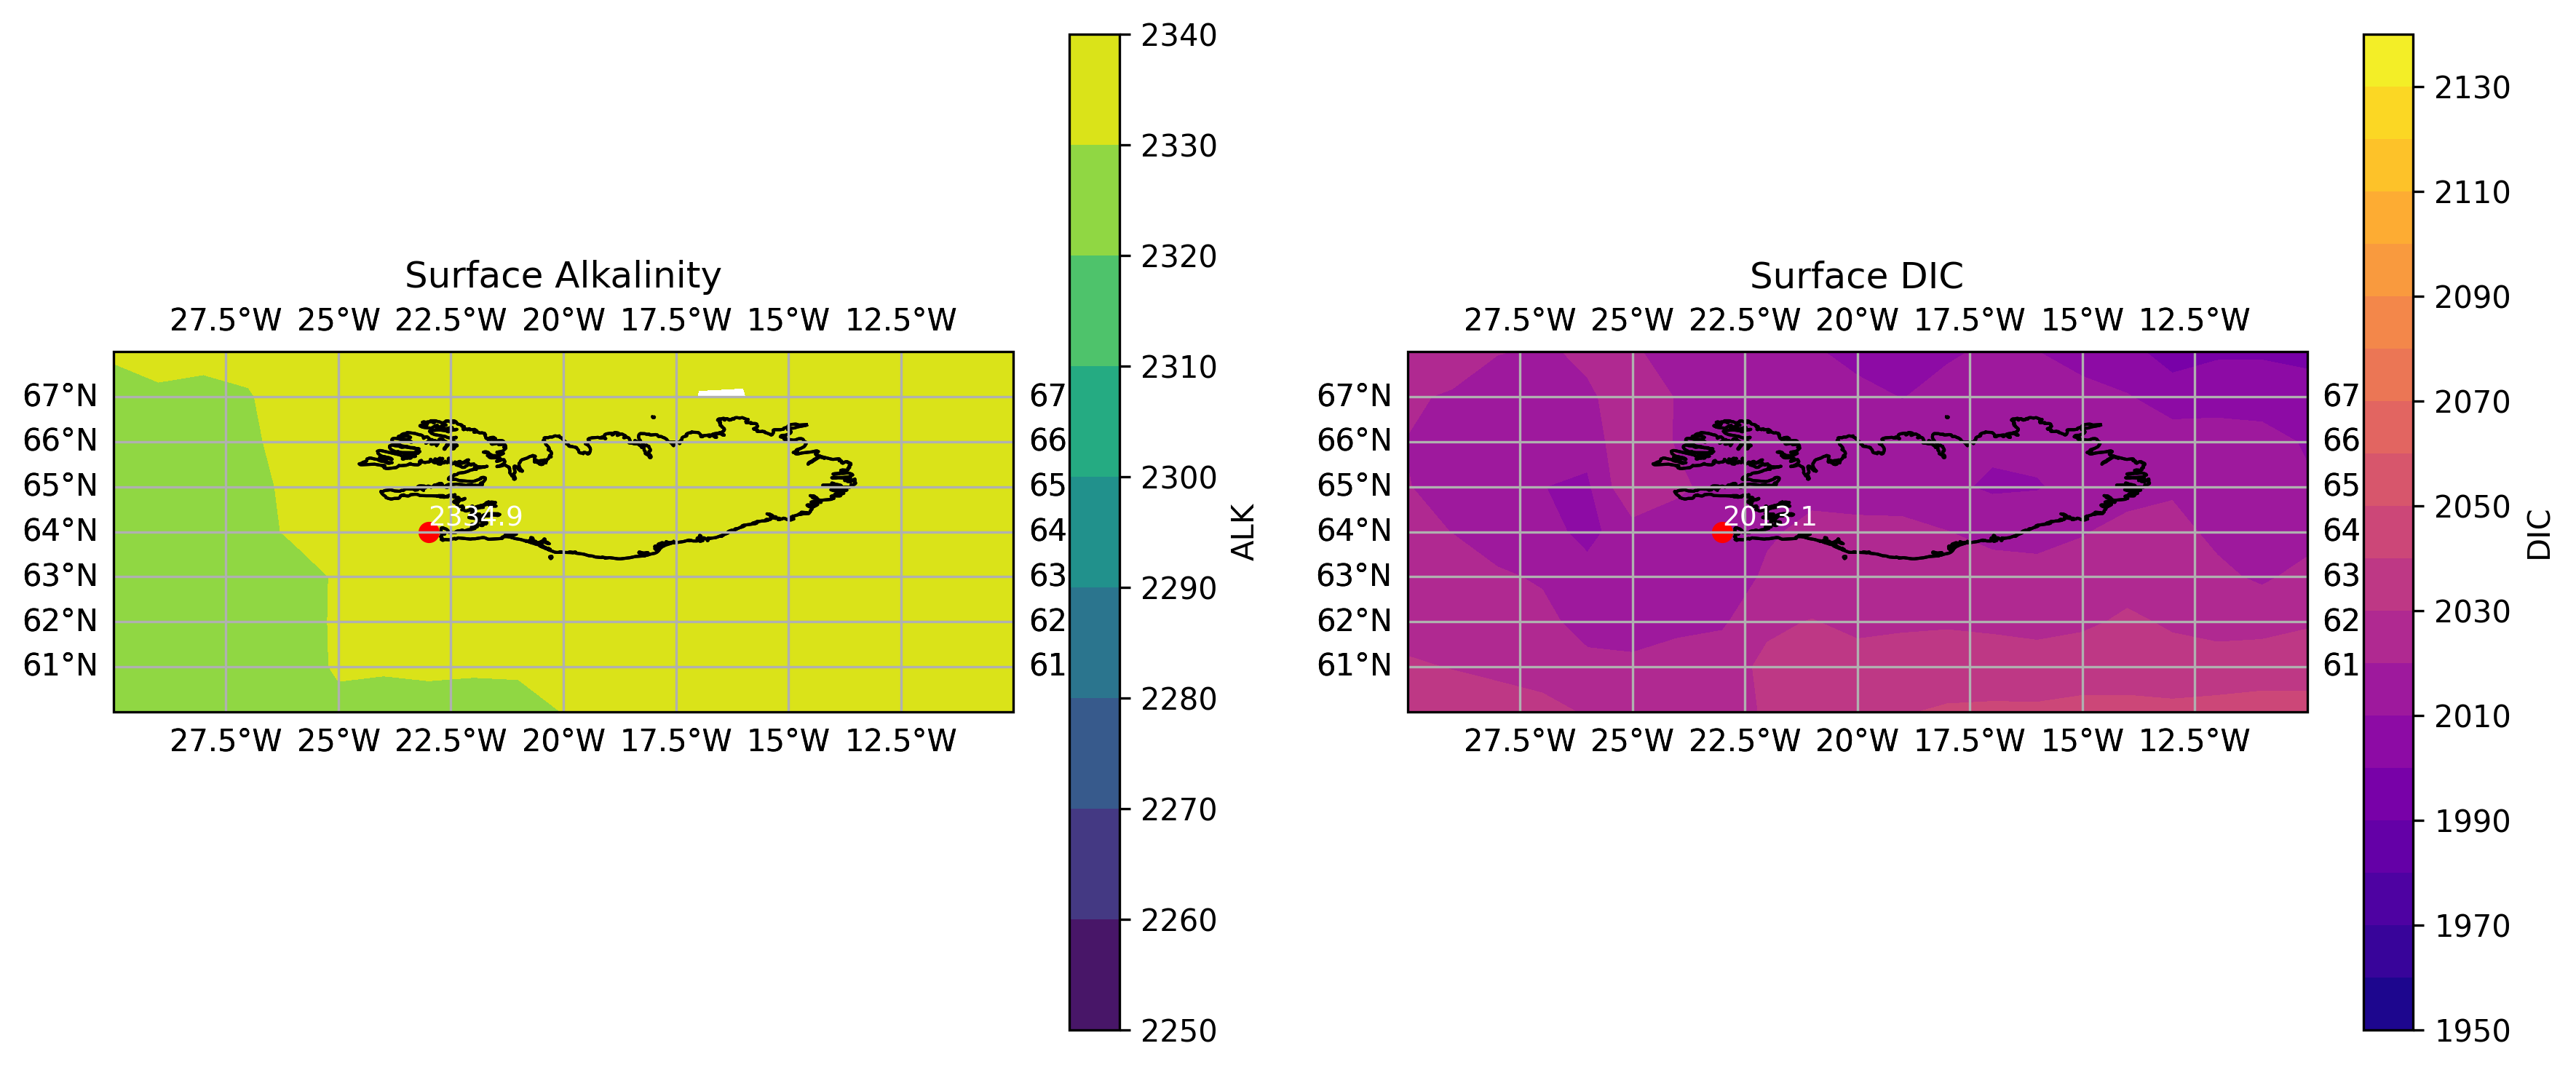

In [48]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --------------------------------------------------
# Open dataset
# --------------------------------------------------
ds = xr.open_dataset(
    "/anvil/projects/x-ees250129/Datasets/UNIFIED/BGCdataset.nc"
)

# --------------------------------------------------
# Select surface layer
# (adjust if your vertical dimension has a different name)
# --------------------------------------------------
if "dep" in ds.dims:
    Alk_surf = ds["Alk"].isel(dep=0)
    DIC_surf = ds["DIC"].isel(dep=0)
elif "z" in ds.dims:
    Alk_surf = ds["Alk"].isel(z=0)
    DIC_surf = ds["DIC"].isel(z=0)
else:
    raise ValueError("No recognized vertical dimension found.")

# --------------------------------------------------
# Coordinates
# --------------------------------------------------
lat = ds["lat"]
lon = ds["lon"]

# --------------------------------------------------
# Southwest Iceland reference point
# (near Reykjanes Peninsula)
# --------------------------------------------------
lat_sw = 63.8
lon_sw = -22.5

# Convert lon if dataset is 0–360
if lon.max() > 180:
    lon_sw = lon_sw % 360

# --------------------------------------------------
# Find nearest grid cell
# --------------------------------------------------
dist2 = (lat - lat_sw)**2 + (lon - lon_sw)**2
j, i = np.unravel_index(dist2.argmin().values, dist2.shape)

lat_pt = lat[j].values
lon_pt = lon[i].values

alk_pt = Alk_surf[7,j, i].values
dic_pt = DIC_surf[7,j, i].values

print(f"Closest grid cell to SW Iceland:")
print(f"  Lat, Lon = {lat_pt:.3f}, {lon_pt:.3f}")
print(f"  Surface ALK = {alk_pt:.2f}")
print(f"  Surface DIC = {dic_pt:.2f}")

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axs = plt.subplots(
    ncols=2,
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    dpi=300
)

# ---- ALK ----
cf1 = axs[0].contourf(
    lon, lat, Alk_surf.isel(month=7),
    levels=np.arange(2250,2350,10),
    cmap="viridis",
    transform=ccrs.PlateCarree()
)
axs[0].plot(lon_pt, lat_pt, "ro", transform=ccrs.PlateCarree())
axs[0].set_title("Surface Alkalinity")
plt.colorbar(cf1, ax=axs[0], orientation="vertical", label="ALK")

axs[0].text(
    lon_pt, lat_pt,
    f"{alk_pt:.1f}",
    color="white",
    fontsize=9,
    ha="left",
    va="bottom",
    transform=ccrs.PlateCarree()
)

# ---- DIC ----
cf2 = axs[1].contourf(
    lon, lat, DIC_surf.isel(month=7),
    levels=np.arange(1950,2150,10),
    cmap="plasma",
    transform=ccrs.PlateCarree()
)
axs[1].plot(lon_pt, lat_pt, "ro", transform=ccrs.PlateCarree())
axs[1].set_title("Surface DIC")
plt.colorbar(cf2, ax=axs[1], orientation="vertical", label="DIC")

axs[1].text(
    lon_pt, lat_pt,
    f"{dic_pt:.1f}",
    color="white",
    fontsize=9,
    ha="left",
    va="bottom",
    transform=ccrs.PlateCarree()
)

for ax in axs:
    ax.coastlines()
    ax.gridlines(draw_labels=True)


# --------------------------------------------------
# (SW Iceland–centered, but includes whole island)
lon_min, lon_max = -30, -10
lat_min, lat_max = 60, 68

axs[0].set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())
axs[0].coastlines(resolution="10m")
axs[0].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

axs[1].set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())
axs[1].coastlines(resolution="10m")
axs[1].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)



plt.tight_layout()
plt.show()
